# **INFORMATION**

## Thông tin sinh viên
- Lớp: DHKHMT19A
- MSSV: 23722291
- Họ tên: Cao Huỳnh Trung Kiên
- Số máy: 15
- Tên file: 2372291_CHTrungKien_M15.ipynb

# **DESCRIPTION**


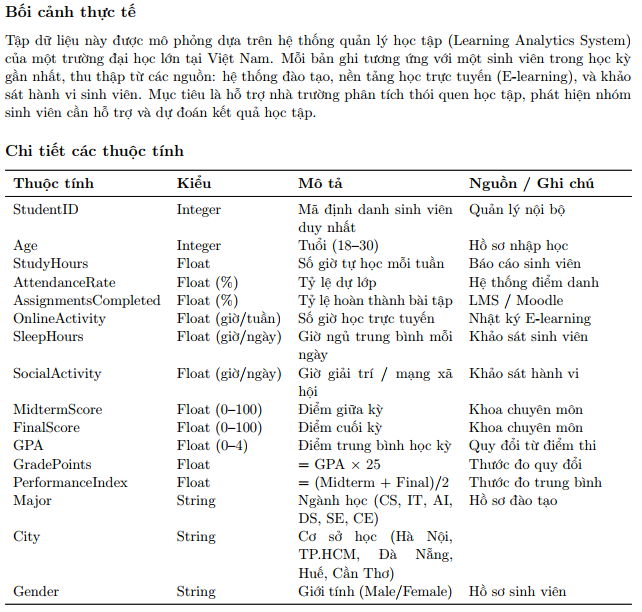

# **IMPORT LIBRARIES**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

# **CODE HERE**

## **Data Preparation And Preprocessing**

In [2]:
# Đọc CSV
data = pd.read_csv('students_performance_practice.csv')

In [3]:
# Hiển thị thông tin cơ bản về dữ liệu
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   StudentID             10000 non-null  int64  
 1   Age                   10000 non-null  int64  
 2   StudyHours            9500 non-null   float64
 3   AttendanceRate        9500 non-null   float64
 4   AssignmentsCompleted  10000 non-null  float64
 5   OnlineActivity        9500 non-null   float64
 6   SleepHours            10000 non-null  float64
 7   SocialActivity        10000 non-null  float64
 8   MidtermScore          10000 non-null  float64
 9   FinalScore            10000 non-null  float64
 10  GPA                   10000 non-null  float64
 11  GradePoints           10000 non-null  float64
 12  PerformanceIndex      10000 non-null  float64
 13  Major                 10000 non-null  object 
 14  City                  10000 non-null  object 
 15  Gender              

In [4]:
# Hiển thị 5 dòng đầu tiên của dữ liệu
data.head()

,StudentID,Age,StudyHours,AttendanceRate,AssignmentsCompleted,OnlineActivity,SleepHours,SocialActivity,MidtermScore,FinalScore,GPA,GradePoints,PerformanceIndex,Major,City,Gender
0,1,24,32.0,91.3,59.1,7.7,5.8,2.9,71.2,92.8,3.67,91.87,82.00,IT,Cần Thơ,Female
1,2,21,15.5,78.4,77.9,6.3,6.2,0.2,59.8,82.2,2.94,73.52,70.98,CE,Hà Nội,Male
2,3,30,29.7,90.0,67.2,6.2,8.1,2.2,65.5,93.9,3.61,90.34,79.68,SE,Hà Nội,Male
3,4,28,30.0,89.8,96.6,4.5,6.1,0.0,61.5,87.0,3.74,93.57,74.24,CS,Cần Thơ,Male
4,5,25,9.7,71.2,89.1,5.9,7.6,3.1,58.0,76.4,3.20,80.04,67.24,CS,Đà Nẵng,Male


In [5]:
# Loại bỏ các hàng bị thiếu dữ liệu của cột AttendanceRate 
data = data.dropna(subset=['AttendanceRate'])

In [6]:
# Điền giá trị thiếu của cột StudyHours và OnlineActivity bằng giá trị trung vị
data.fillna({
    'StudyHours': data['StudyHours'].median(),
    'OnlineActivity': data['OnlineActivity'].median()
}, inplace=True)

In [7]:
# Tính ma trận tương quan
corr_matrix = data.select_dtypes(include=['int64', 'float64']).corr()

# In ra kết quả
corr_matrix

,StudentID,Age,StudyHours,AttendanceRate,AssignmentsCompleted,OnlineActivity,SleepHours,SocialActivity,MidtermScore,FinalScore,GPA,GradePoints,PerformanceIndex
StudentID,1.000000,0.006326,0.013196,-0.019979,-0.010720,0.025020,0.009160,0.018468,0.002716,0.007551,0.005515,0.005518,0.006043
Age,0.006326,1.000000,-0.000353,-0.003567,-0.008419,-0.011135,0.003319,-0.007588,0.000330,-0.001475,-0.005660,-0.005718,-0.000783
StudyHours,0.013196,-0.000353,1.000000,0.005250,0.022582,-0.012352,-0.017759,-0.008668,0.606514,0.729809,0.680479,0.680521,0.744312
AttendanceRate,-0.019979,-0.003567,0.005250,1.000000,0.023410,0.016744,-0.004509,0.004180,0.135726,0.228572,0.217695,0.217754,0.207340
AssignmentsCompleted,-0.010720,-0.008419,0.022582,0.023410,1.000000,0.008252,0.001310,0.002664,0.022470,0.024752,0.022422,0.022391,0.026177
OnlineActivity,0.025020,-0.011135,-0.012352,0.016744,0.008252,1.000000,0.010760,-0.002182,0.000184,-0.002012,-0.000413,-0.000513,-0.001173
SleepHours,0.009160,0.003319,-0.017759,-0.004509,0.001310,0.010760,1.000000,-0.012448,0.002523,-0.004030,-0.005278,-0.005228,-0.001302
SocialActivity,0.018468,-0.007588,-0.008668,0.004180,0.002664,-0.002182,-0.012448,1.000000,-0.003440,-0.033586,-0.027717,-0.027637,-0.022618
MidtermScore,0.002716,0.000330,0.606514,0.135726,0.022470,0.000184,0.002523,-0.003440,1.000000,0.645867,0.608833,0.608867,0.878829
FinalScore,0.007551,-0.001475,0.729809,0.228572,0.024752,-0.002012,-0.004030,-0.033586,0.645867,1.000000,0.935892,0.935933,0.931874


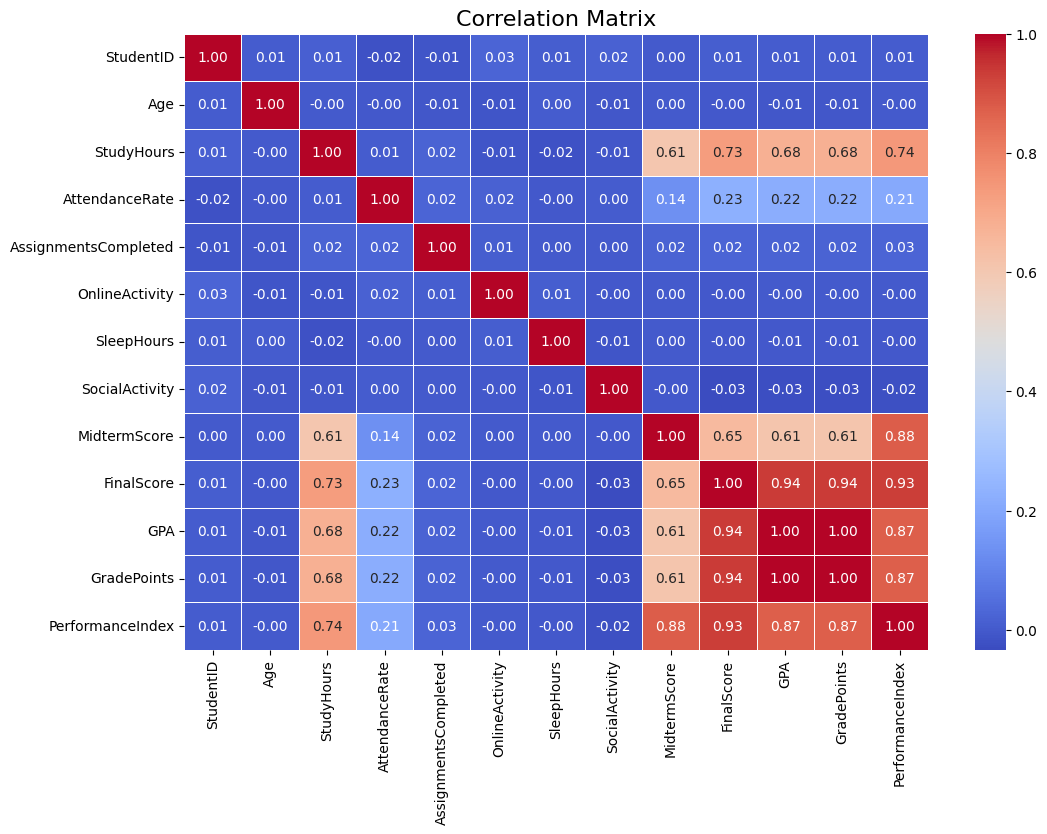

In [8]:
plt.figure(figsize=(12, 8))  # kích thước hình
sns.heatmap(corr_matrix,
            annot=True,       # hiển thị số tương quan
            cmap="coolwarm",  # bảng màu dễ nhìn
            fmt=".2f",        # format 2 chữ số thập phân
            linewidths=0.5)   # đường ngăn ô

plt.title("Correlation Matrix", fontsize=16)
plt.show()

In [9]:
# Các cột có thuộc tính tuyến tính và không cần thiết
to_drop = ['GPA', 'GradePoints', 'PerformanceIndex', 'StudentID']

# Loai bỏ các cột này khỏi dữ liệu
X_train = data.drop(columns=to_drop)

In [10]:
# Các cột dạng object
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

In [11]:
# Các cột dạng numeric sau khi loại bỏ
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [12]:
# Tiền xử lý dữ liệu
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

## **KMeans Clustering**

In [13]:
# Xây dựng pipeline KMeans
pipe = Pipeline(steps=[
    ('prep', preprocess),
    ('kmeans', KMeans(n_clusters=4, random_state=42, n_init=10))
])

# Huấn luyện mô hình
pipe.fit(X_train)

# Lấy nhãn cluster sau khi huấn luyện
labels = pipe.named_steps['kmeans'].labels_

# Gán nhãn cụm vào dữ liệu gốc
data_final = X_train.copy()
data_final['Cluster'] = labels

In [14]:
# Thống kê số lượng sinh viên trong mỗi cụm
data_final['Cluster'].value_counts()

Cluster
2    2629
1    2574
0    2262
3    2035
Name: count, dtype: int64

## **Evaluate The Model**

In [15]:
# Lấy dữ liệu đã được biến đổi sau tiền xử lý
X_transformed = pipe.named_steps['prep'].transform(X_train)

# Tính silhouette score
sil_score = silhouette_score(X_transformed, labels)
print(f'Silhouette Score: {sil_score:.4f}')

Silhouette Score: 0.0740


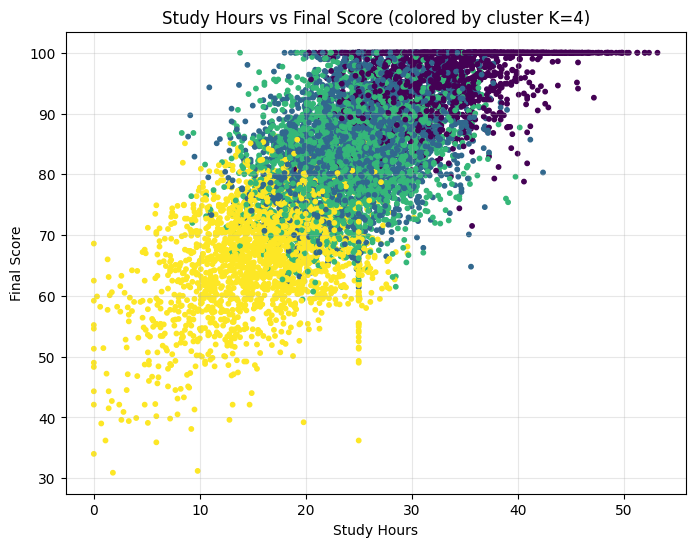

In [16]:
# Sao chép dữ liệu gốc để phân tích thêm
data_analyzed = data.copy()

# Vẽ scatter (StudyHours vs FinalScore)
plt.figure(figsize=(8, 6))
plt.scatter(data_analyzed["StudyHours"], data_analyzed["FinalScore"], c=data_final["Cluster"], s=10)
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.title(f"Study Hours vs Final Score (colored by cluster K=4)")
plt.grid(alpha=0.3)
plt.show()

## **Determine The Optimal Number Of Groups**

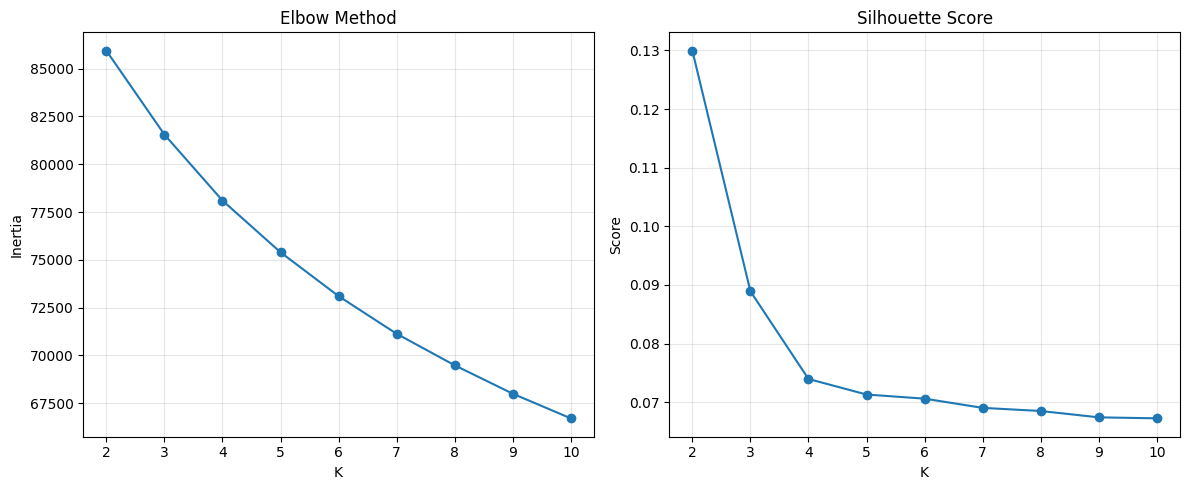

Inertia: {2: 85938.06401750383, 3: 81551.28119602462, 4: 78100.64791311577, 5: 75394.68964936488, 6: 73101.3824946022, 7: 71131.95316679077, 8: 69483.93935616133, 9: 67997.59700842248, 10: 66708.62909930544}
Silhouette: {2: np.float64(0.1299541367332423), 3: np.float64(0.08891628583792166), 4: np.float64(0.07396180243487505), 5: np.float64(0.07130780176498398), 6: np.float64(0.07060379559892065), 7: np.float64(0.0690347457896548), 8: np.float64(0.06849880662197487), 9: np.float64(0.0674172732643099), 10: np.float64(0.06724677532772237)}


In [17]:
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    pipe_k = Pipeline(steps=[
        ('prep', preprocess),
        ('kmeans', KMeans(n_clusters=k, random_state=42, n_init=10))
    ])
    
    labels_k = pipe_k.fit_predict(X_train)
    inertias.append(pipe_k.named_steps['kmeans'].inertia_)
    sil_scores.append(silhouette_score(pipe_k.named_steps['prep'].transform(X_train), labels_k))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("K")
plt.ylabel("Score")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Inertia:", dict(zip(K_range, inertias)))
print("Silhouette:", dict(zip(K_range, sil_scores)))